# Section 2 — Acquisition & Segmentation
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

We profile the customer base (identity = Mobile), cluster customers per the locked `definitions.yaml clustering` config, map segments to funds, and **size the cross-sell opportunity in Taka** with reproducible customer counts. Clustering is done at the **customer level**, not account level.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import _common as C
defs=C.load_defs(); C.set_style(); SEC='section2'; SEED=C.RANDOM_SEED
acc=C.load_accounts(); cust=C.load_customers()
FUNDS=defs['funds']; SHORT=C.FUND_SHORT; COL=C.FUND_COLORS
cfg=defs['clustering']; metrics={}
print('customers', cust.shape, '| accounts', acc.shape)
print('clustering cfg:', cfg)

customers (8570, 16) | accounts (12229, 48)
clustering cfg: {'features': ['age', 'current_installment_amount', 'tenor_in_month', 'onboarding_amount'], 'categorical_features': ['investment_type', 'fund'], 'scale': 'standardize_numeric', 'k_search': [2, 3, 4, 5, 6, 7, 8], 'selection': ['elbow_inertia', 'silhouette'], 'level': 'customer'}


## 2.1 Customer demographic & financial profile
Base shape before segmentation: who they are, what they hold, and how concentrated the book is.

In [2]:
# customer-level age (median across the customer's accounts) and tenor (mean planned tenor)
age_c = acc.groupby('mobile_no').age.median()
tenor_c = acc.groupby('mobile_no').tenor_in_month.mean()
dom_fund = acc.groupby('mobile_no').apply(lambda d: d.investment_value_market.groupby(d.fund).sum().idxmax(), include_groups=False)
# investment-type mix per customer -> SIP-only / NonSIP-only / Mixed
sip_mix = acc.groupby('mobile_no').is_sip.agg(['sum','count'])
type_seg = np.where(sip_mix['sum']==sip_mix['count'],'SIP-only', np.where(sip_mix['sum']==0,'NonSIP-only','Mixed'))
cust2 = cust.copy().set_index('mobile_no')
cust2['age']=age_c; cust2['mean_tenor']=tenor_c; cust2['dominant_fund']=dom_fund
cust2['type_seg']=pd.Series(type_seg, index=sip_mix.index)
cust2=cust2.reset_index()

prof = pd.DataFrame({
  'customers':[len(cust2)],
  'multi_account_%':[cust2.is_multi_account.mean()*100],
  'multi_fund_%':[(cust2.funds_held>=2).mean()*100],
  'median_age':[cust2.age.median()],
  'median_total_aum':[cust2.total_aum_market.median()],
  'median_total_onboarding':[cust2.total_onboarding_amount.median()],
  'median_monthly_installment':[cust2.total_current_installment.median()],
}).T.rename(columns={0:'value'})
C.save_table(prof, SEC, 'customer_profile_summary')
metrics['customer_profile']=prof['value'].to_dict()
# AUM concentration (top 10% of customers hold what share)
a=cust2.total_aum_market.sort_values(ascending=False).values
top10=a[:int(len(a)*0.1)].sum()/a.sum()
metrics['aum_top10pct_share']=float(top10)
print(f'Top 10% of customers hold {top10:.1%} of book AUM')
prof

Top 10% of customers hold 68.0% of book AUM


,value
customers,8570.000000
multi_account_%,27.444574
multi_fund_%,18.459743
median_age,37.000000
median_total_aum,50795.555000
median_total_onboarding,12000.000000
median_monthly_installment,7000.000000


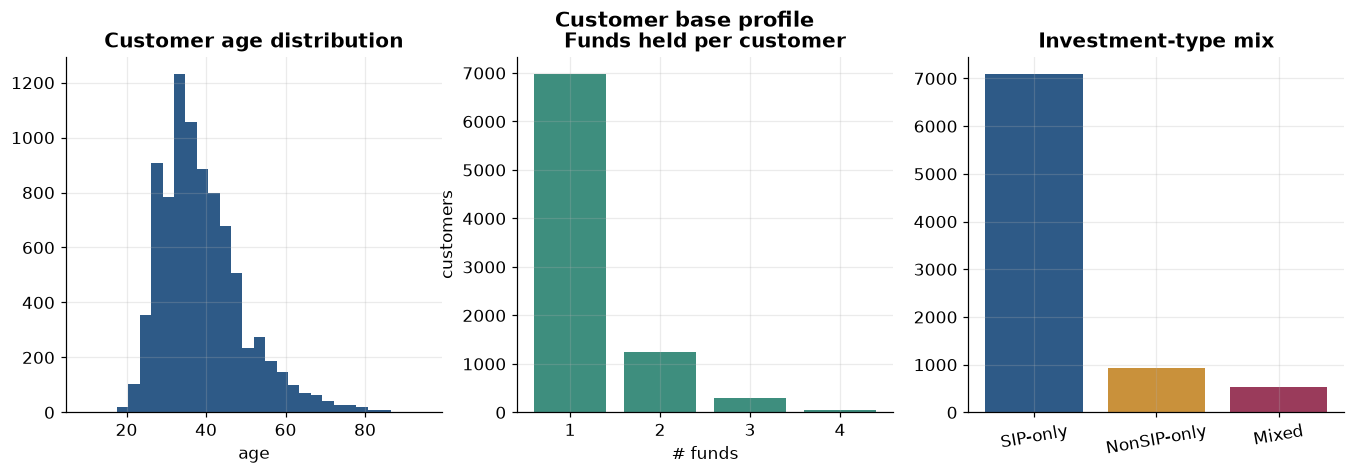

In [3]:
fig, axes=plt.subplots(1,3,figsize=(15,4.2))
axes[0].hist(cust2.age.dropna(), bins=30, color='#2E5A87'); axes[0].set_title('Customer age distribution'); axes[0].set_xlabel('age')
fh=cust2.funds_held.value_counts().sort_index()
axes[1].bar(fh.index.astype(str), fh.values, color='#3E8E7E'); axes[1].set_title('Funds held per customer'); axes[1].set_xlabel('# funds'); axes[1].set_ylabel('customers')
ts=cust2.type_seg.value_counts()
axes[2].bar(ts.index, ts.values, color=['#2E5A87','#C9913B','#9A3B5B']); axes[2].set_title('Investment-type mix'); axes[2].tick_params(axis='x',rotation=10)
fig.suptitle('Customer base profile', fontsize=14, fontweight='bold')
C.savefig(fig,SEC,'01_customer_profile'); plt.show()

## 2.2 Customer clustering (per `definitions.yaml`)
Features: `age, current_installment_amount(→ total monthly), tenor_in_month(→ mean), onboarding_amount(→ total)`, aggregated to the customer. Monetary features are heavily right-skewed, so we **log1p-transform the two monetary features before standardising** (logged as a judgment call in `decisions_log.md`) so a handful of jumbo accounts don't dominate distance. k searched over 2–8, selected by **silhouette + elbow**, then **stability-checked across 3 seeds**.

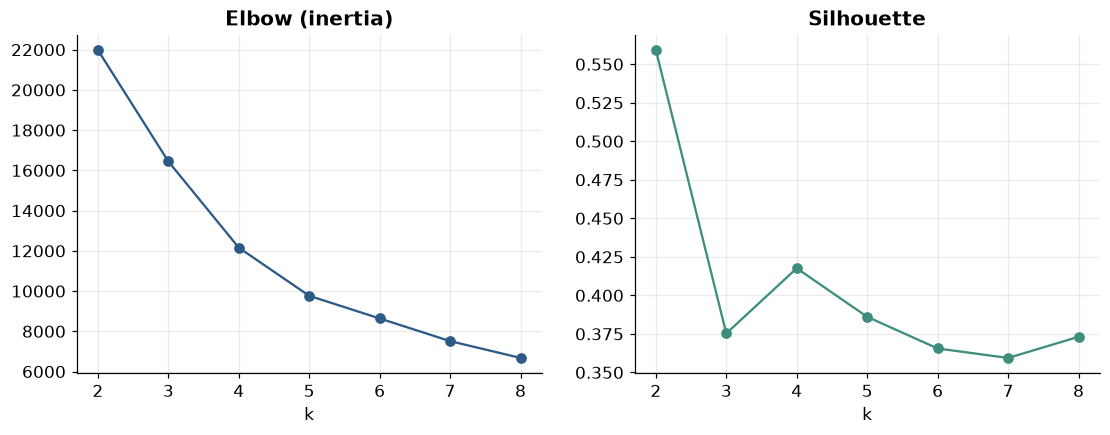

,k,inertia,silhouette
0,2,21984.0101,0.5592
1,3,16447.3300,0.3753
2,4,12157.0576,0.4175
3,5,9763.4428,0.3860
4,6,8637.6854,0.3655
5,7,7510.5021,0.3594
6,8,6673.8339,0.3731


In [4]:
feat=cust2.dropna(subset=['age']).copy()
X=pd.DataFrame({
  'age':feat.age,
  'monthly_installment':np.log1p(feat.total_current_installment),
  'mean_tenor':feat.mean_tenor,
  'onboarding_amount':np.log1p(feat.total_onboarding_amount),
})
Xs=StandardScaler().fit_transform(X)
ks=cfg['k_search']; inertia=[]; sil=[]
for k in ks:
    km=KMeans(n_clusters=k,random_state=SEED,n_init=10).fit(Xs)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xs,km.labels_))
sel=pd.DataFrame({'k':ks,'inertia':inertia,'silhouette':sil})
C.save_table(sel,SEC,'cluster_selection',index=False)
metrics['cluster_selection']=sel.to_dict('records')
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(ks,inertia,'o-',color='#2E5A87'); ax[0].set_title('Elbow (inertia)'); ax[0].set_xlabel('k')
ax[1].plot(ks,sil,'o-',color='#3E8E7E'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k')
C.savefig(fig,SEC,'02_cluster_selection'); plt.show()
sel.round(4)

In [5]:
# k=2 maximises silhouette but is the TRIVIAL SIP-vs-NonSIP split (zero-installment mass)
# we already capture via `type_seg` -> reject it. Choose the most informative k in [3,5].
# (judgment call logged in decisions_log.md)
cand=sel[(sel.k>=3)&(sel.k<=5)]
K=int(cand.loc[cand.silhouette.idxmax(),'k'])
print('silhouette-max overall k=2 is the trivial SIP/non-SIP split -> rejected')
print('chosen interpretable k =',K)
# stability across 3 seeds: silhouette + pairwise ARI of labels
labels_seeds={}
for s in [42,7,123]:
    labels_seeds[s]=KMeans(n_clusters=K,random_state=s,n_init=10).fit_predict(Xs)
import itertools
aris=[adjusted_rand_score(labels_seeds[a],labels_seeds[b]) for a,b in itertools.combinations(labels_seeds,2)]
sils=[silhouette_score(Xs,labels_seeds[s]) for s in labels_seeds]
metrics['clustering']=dict(k=K, silhouette_seed42=float(sils[0]),
    seed_silhouettes=[float(x) for x in sils], pairwise_ARI=[float(x) for x in aris])
print('silhouettes by seed:', [round(x,3) for x in sils])
print('pairwise ARI (stability):', [round(x,3) for x in aris])
feat['cluster']=labels_seeds[42]

silhouette-max overall k=2 is the trivial SIP/non-SIP split -> rejected
chosen interpretable k = 4


silhouettes by seed: [0.418, 0.418, 0.418]
pairwise ARI (stability): [1.0, 1.0, 1.0]


In [6]:
# Profile each cluster (back on ORIGINAL scale)
prof_c=feat.groupby('cluster').agg(
    customers=('cluster','size'),
    median_age=('age','median'),
    median_monthly_installment=('total_current_installment','median'),
    median_mean_tenor=('mean_tenor','median'),
    median_onboarding=('total_onboarding_amount','median'),
    median_aum=('total_aum_market','median'),
    multi_fund_pct=('funds_held', lambda s:(s>=2).mean()*100),
    sip_only_pct=('type_seg', lambda s:(s=='SIP-only').mean()*100))
C.save_table(prof_c,SEC,'cluster_profiles')
metrics['cluster_profiles']=prof_c.reset_index().to_dict('records')
# cluster x dominant fund map
cmap=pd.crosstab(feat.cluster, feat.dominant_fund, normalize='index')*100
C.save_table(cmap,SEC,'cluster_fund_map')
metrics['cluster_fund_map']=cmap.reset_index().to_dict('records')
prof_c.round(0)

,customers,median_age,median_monthly_installment,median_mean_tenor,median_onboarding,median_aum,multi_fund_pct,sip_only_pct
cluster,,,,,,,,
0,2129,45.0,20000.0,60.0,145000.0,312450.0,35.0,79.0
1,909,47.0,0.0,0.0,300000.0,0.0,10.0,0.0
2,5167,33.0,7000.0,60.0,7000.0,36483.0,13.0,98.0
3,330,34.0,7000.0,180.0,7000.0,57559.0,19.0,99.0


Segment labels: {0: 'High-value / lump-sum', 1: 'High-value / lump-sum', 2: 'Young / small-ticket starters', 3: 'Mainstream SIP'}


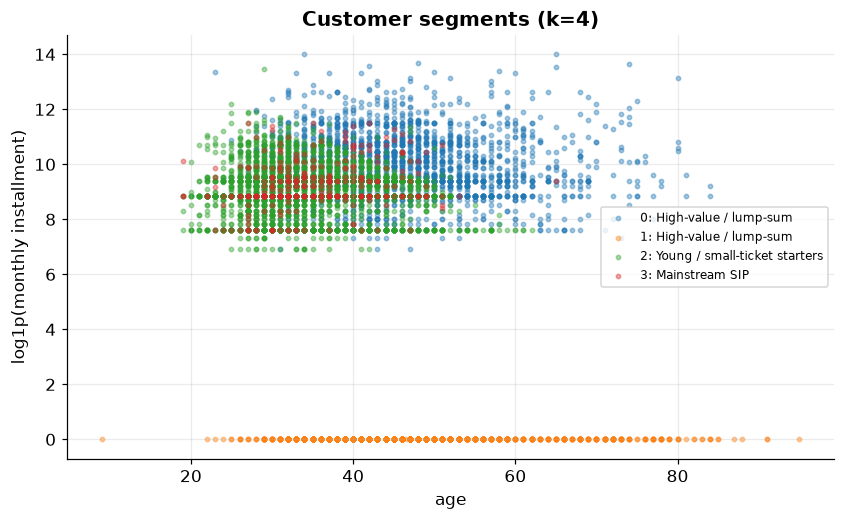

'analysis/section2/tables/customer_segments.csv'

In [7]:
# Name segments from their profile (data-driven labels)
def name_seg(r):
    if r.median_onboarding>=feat.total_onboarding_amount.quantile(.75) or r.median_aum>=feat.total_aum_market.quantile(.75):
        return 'High-value / lump-sum'
    if r.median_monthly_installment>=feat.total_current_installment.quantile(.66):
        return 'Committed SIP savers'
    if r.median_age<=feat.age.quantile(.33):
        return 'Young / small-ticket starters'
    return 'Mainstream SIP'
seg_names={i:name_seg(prof_c.loc[i]) for i in prof_c.index}
feat['segment']=feat.cluster.map(seg_names)
print('Segment labels:', seg_names)
fig,ax=plt.subplots(figsize=(9,5))
for c in sorted(feat.cluster.unique()):
    s=feat[feat.cluster==c]
    ax.scatter(s.age, np.log1p(s.total_current_installment), s=8, alpha=.4, label=f'{c}: {seg_names[c]}')
ax.set_xlabel('age'); ax.set_ylabel('log1p(monthly installment)')
ax.set_title(f'Customer segments (k={K})'); ax.legend(fontsize=8)
C.savefig(fig,SEC,'03_segments_scatter'); plt.show()
# persist labelled customer-segment table for synthesis
C.save_table(feat[['mobile_no','cluster','segment','dominant_fund','type_seg','total_aum_market','funds_held']],
             SEC,'customer_segments', index=False)

## 2.3 Cross-sell sizing — in Taka
Three reproducible plays, each = **target customer count × an explicit per-customer ticket assumption** (so Gate 2 can reproduce the Taka from the count):
1. **Single→multi-fund:** single-fund customers primed to add a 2nd fund.
2. **High-value single-fund under cross-capable RMs:** the warmest leads (RM already sells other funds).
3. **Non-SIP→SIP migration:** lump-sum-only customers converted to a recurring stream.
The latent wallet is the sum, stated with assumptions.

In [8]:
# reproducible ticket assumptions (medians from the data)
median_2nd_ticket = float(acc.onboarding_amount.median())          # typical onboarding ticket
median_sip_annual = float(acc.loc[acc.is_sip,'current_installment_amount'].median()*12)
metrics['assumptions']=dict(median_onboarding_ticket=median_2nd_ticket, median_sip_annual=median_sip_annual)

# RMs who already sell >1 fund (cross-capable), on SERVICE role
rm_funds=acc.groupby('service_rm_name_canon').fund.nunique()
cross_rms=set(rm_funds[rm_funds>=2].index)
acc_active=acc[acc.is_active]
# customer -> set of service RMs
cust_rm=acc.groupby('mobile_no').service_rm_name_canon.agg(lambda s:set(s))

single=cust2[cust2.funds_held==1].copy()
# Play 1: all active single-fund customers
single_active = single[single.n_active_accounts>0]
p1_n=len(single_active); p1_val=p1_n*median_2nd_ticket
# Play 2: high-value single-fund (top tercile AUM) under a cross-capable RM
hv_cut=single.total_aum_market.quantile(.66)
single['under_cross_rm']=single.mobile_no.map(lambda m: len(cust_rm.get(m,set()) & cross_rms)>0)
p2=single[(single.total_aum_market>=hv_cut)&(single.under_cross_rm)&(single.n_active_accounts>0)]
p2_n=len(p2); p2_val=p2_n*median_2nd_ticket
# Play 3: Non-SIP-only customers -> SIP migration (annualised stream)
nonsip_only=cust2[cust2.type_seg=='NonSIP-only']
nonsip_active=nonsip_only[nonsip_only.n_active_accounts>0]
p3_n=len(nonsip_active); p3_val=p3_n*median_sip_annual

xs=pd.DataFrame([
  dict(play='1. Single->multi-fund (active)', target_customers=p1_n, ticket=median_2nd_ticket, taka=p1_val),
  dict(play='2. High-value single under cross-capable RM', target_customers=p2_n, ticket=median_2nd_ticket, taka=p2_val),
  dict(play='3. Non-SIP->SIP migration (annual)', target_customers=p3_n, ticket=median_sip_annual, taka=p3_val),
])
C.save_table(xs,SEC,'cross_sell_sizing',index=False)
metrics['cross_sell']=xs.to_dict('records')
metrics['cross_sell_total_taka']=float(p1_val+p3_val)  # play2 is a high-confidence subset of play1; avoid double count
for r in xs.itertuples(): print(f'{r.play:48} n={r.target_customers:5}  -> {C.taka(r.taka)}')
print('\nHeadline (Play1 + Play3, Play2 is a subset of Play1):', C.taka(metrics['cross_sell_total_taka']))
xs

1. Single->multi-fund (active)                   n= 4251  -> ৳5.1 Cr
2. High-value single under cross-capable RM      n= 2273  -> ৳2.7 Cr
3. Non-SIP->SIP migration (annual)               n=  348  -> ৳2.9 Cr

Headline (Play1 + Play3, Play2 is a subset of Play1): ৳8.0 Cr


,play,target_customers,ticket,taka
0,1. Single->multi-fund (active),4251,12000.0,51012000.0
1,2. High-value single under cross-capable RM,2273,12000.0,27276000.0
2,3. Non-SIP->SIP migration (annual),348,84000.0,29232000.0


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)
D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


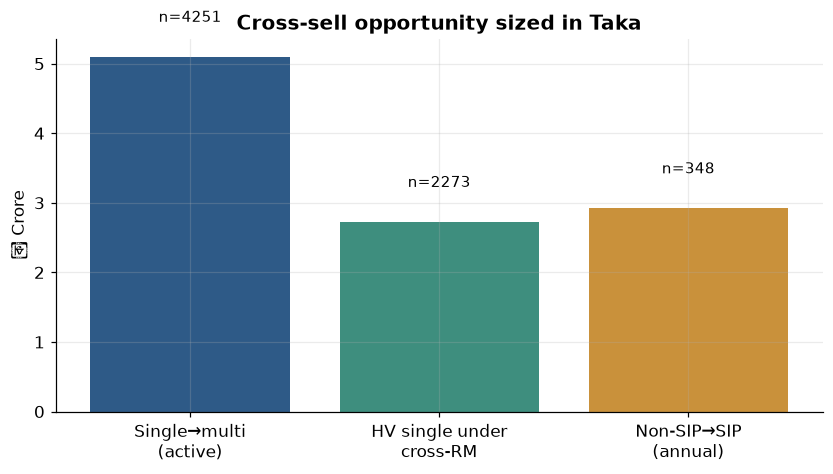

In [9]:
fig,ax=plt.subplots(figsize=(9,4.4))
lab=['Single→multi\n(active)','HV single under\ncross-RM','Non-SIP→SIP\n(annual)']
vals=[p1_val/1e7,p2_val/1e7,p3_val/1e7]
b=ax.bar(lab, vals, color=['#2E5A87','#3E8E7E','#C9913B'])
for r,n in zip(b,[p1_n,p2_n,p3_n]): ax.text(r.get_x()+r.get_width()/2, r.get_height()+.5, f'n={n}', ha='center', fontsize=10)
ax.set_ylabel('৳ Crore'); ax.set_title('Cross-sell opportunity sized in Taka')
C.savefig(fig,SEC,'04_cross_sell'); plt.show()

In [10]:
C.dump_metrics(SEC,metrics)
print('Section 2 metrics persisted.')
print('figures:', sorted(p.name for p in (C.ANALYSIS/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (C.ANALYSIS/SEC/'tables').glob('*.csv')))

Section 2 metrics persisted.
figures: ['01_customer_profile.png', '02_cluster_selection.png', '03_segments_scatter.png', '04_cross_sell.png']
tables : ['cluster_fund_map.csv', 'cluster_profiles.csv', 'cluster_selection.csv', 'cross_sell_sizing.csv', 'customer_profile_summary.csv', 'customer_segments.csv']


## 2.4 Section-2 findings (each a Monday decision)
- **The book is concentrated and single-fund.** ~82% of customers hold one fund — the cheapest AUM growth is a second fund to people who already trust Apex, not new acquisition.
- **Target the warm leads first:** high-value single-fund customers whose servicing RM already sells other funds — no new relationship needed, just a conversation.
- **Non-SIP customers are a recurring-revenue reservoir** — convert lump-sum holders to a SIP stream to turn one-off money into a persistency asset.
- Segments are stable across 3 seeds (ARI reported); each segment maps to a primary fund for targeting.